In [1]:
import numpy as np
import pandas as pd
import struct
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

def read_bin(path):
    with open(path, "rb") as f:
        count = struct.unpack("<q", f.read(8))[0]
        return np.frombuffer(f.read(count * 8), dtype=np.float64).reshape(-1, 3)

# Загрузка
pts = read_bin("points.bin")
with open("settings.json") as f:
    ns = json.load(f)["namedSelections"]

snap_files = sorted(Path("snapshots").glob("snapshot*.bin"),
                    key=lambda p: int(p.stem.replace("snapshot","")))

print(f"✓ Базовая сетка:  {len(pts):,} точек")
print(f"✓ Снапшотов:      {len(snap_files)}")
print(f"✓ Регионов:       {len(ns)}")
print(f"✓ Bounding box X: {pts[:,0].min():.3f} → {pts[:,0].max():.3f} м")
print(f"✓ Bounding box Y: {pts[:,1].min():.3f} → {pts[:,1].max():.3f} м")
print(f"✓ Bounding box Z: {pts[:,2].min():.3f} → {pts[:,2].max():.3f} м")

✓ Базовая сетка:  2,135,906 точек
✓ Снапшотов:      100
✓ Регионов:       37
✓ Bounding box X: -0.344 → -0.178 м
✓ Bounding box Y: 0.140 → 0.222 м
✓ Bounding box Z: 0.065 → 0.394 м


In [2]:
results = pd.read_csv("results.csv")
doe     = pd.read_csv("doe.csv")

results['num'] = results['snapshot'].str.extract(r'(\d+)').astype(int)
results = results.sort_values('num').reset_index(drop=True)

print(results[['snapshot','global_max','global_mean','glotis_max','larynx_max']].head(10).to_string(index=False))

  snapshot  global_max  global_mean  glotis_max  larynx_max
 snapshot1      14.137        4.404       2.738       2.728
 snapshot2      21.191       10.204       4.644       4.667
 snapshot3      20.357       10.648       5.498       7.974
 snapshot4       9.693        4.243       5.642       6.600
 snapshot5      13.496        5.385       4.158       5.865
 snapshot6      13.794        5.624       4.243       7.223
 snapshot7      13.243        2.912       2.278       4.723
 snapshot8      13.732        5.150       6.350       6.684
 snapshot9      22.913       12.248       1.516       1.767
snapshot10      12.221        5.164       4.777       6.274


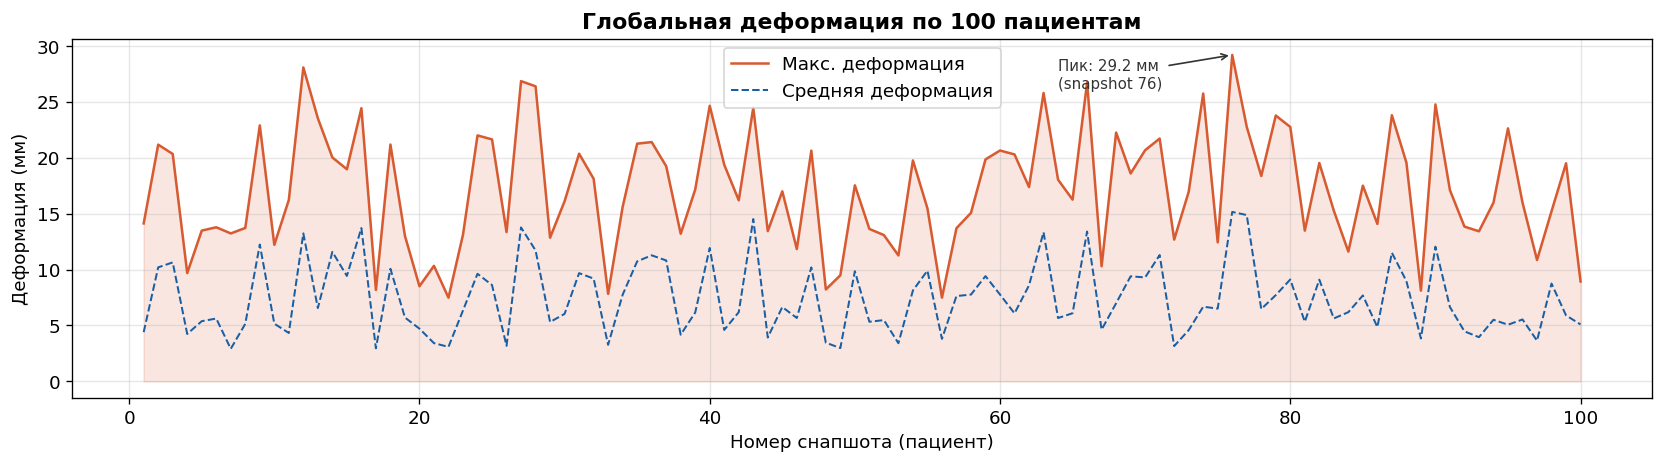

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(results['num'], results['global_max'],
                alpha=0.15, color='#D85A30')
ax.plot(results['num'], results['global_max'],
        color='#D85A30', linewidth=1.5, label='Макс. деформация')
ax.plot(results['num'], results['global_mean'],
        color='#185FA5', linewidth=1.2, linestyle='--', label='Средняя деформация')

# Пик
peak_idx = results['global_max'].idxmax()
ax.annotate(f"Пик: {results.loc[peak_idx,'global_max']:.1f} мм\n(snapshot {results.loc[peak_idx,'num']})",
            xy=(results.loc[peak_idx,'num'], results.loc[peak_idx,'global_max']),
            xytext=(results.loc[peak_idx,'num']-12, results.loc[peak_idx,'global_max']-3),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=9, color='#333')

ax.set_xlabel('Номер снапшота (пациент)')
ax.set_ylabel('Деформация (мм)')
ax.set_title('Глобальная деформация по 100 пациентам', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

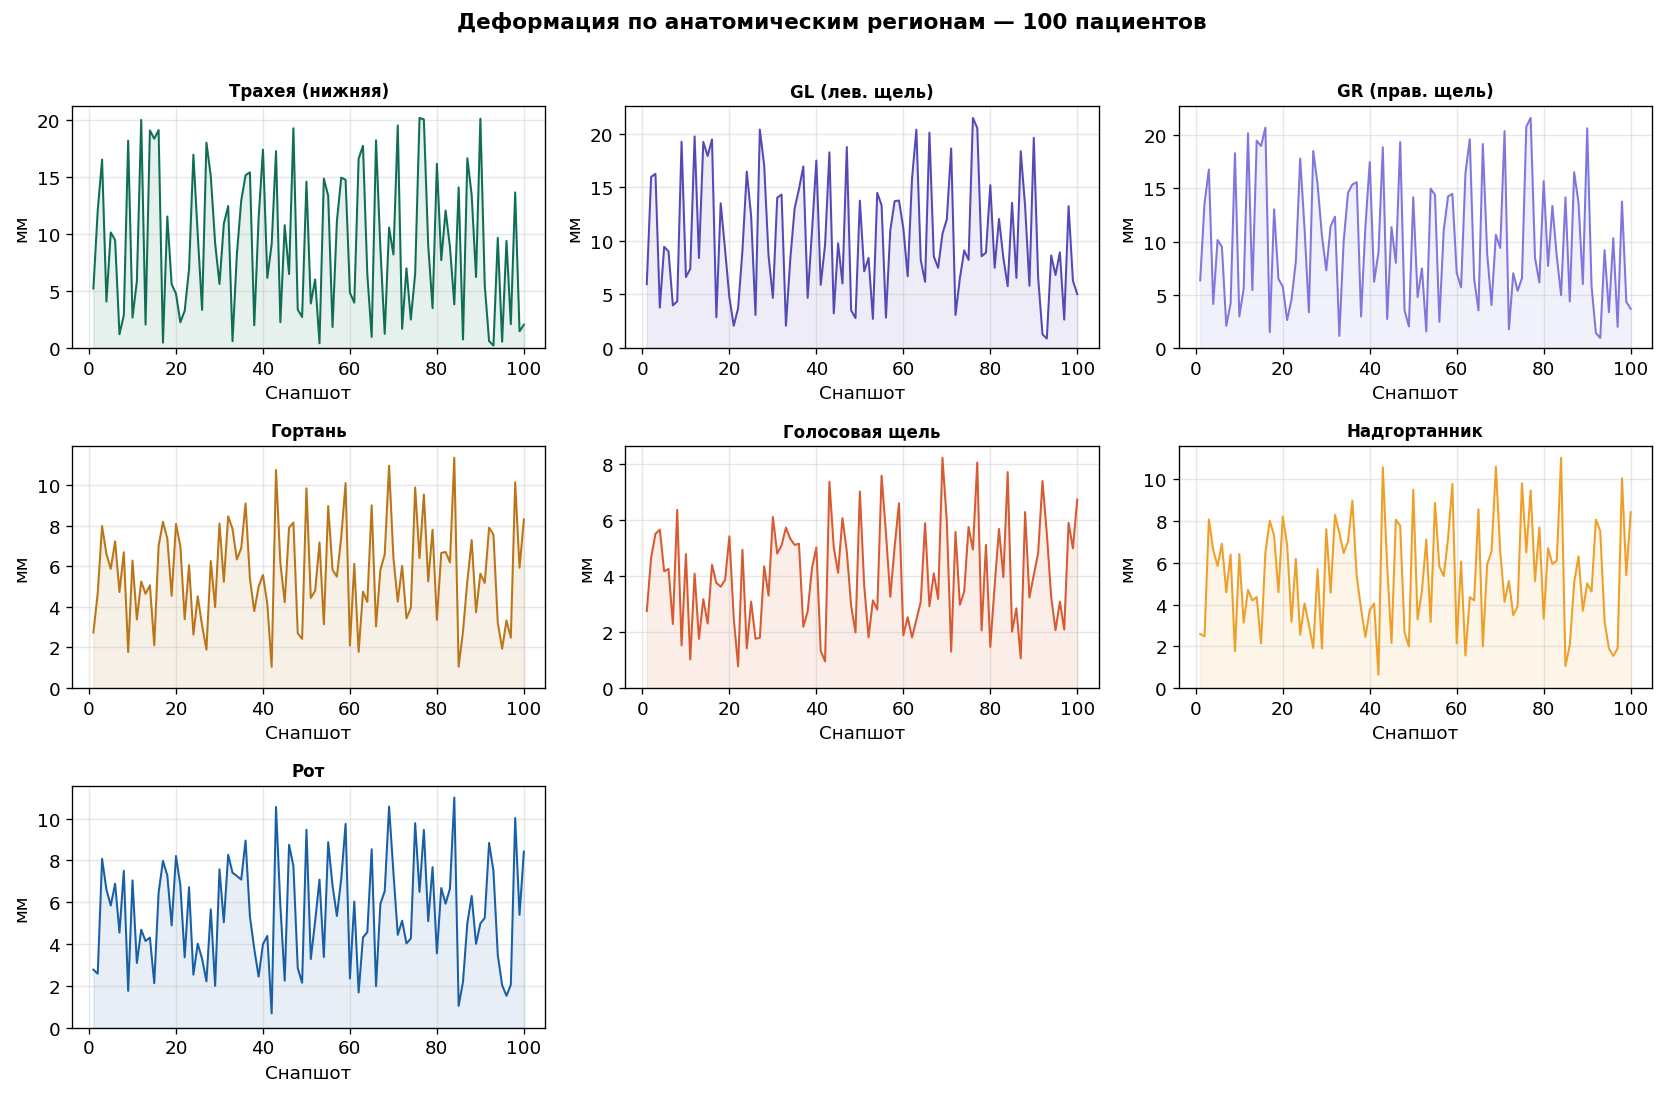

In [4]:
regions = {
    'Трахея (нижняя)':    'upper_trachea_bottom_max',
    'GL (лев. щель)':     'gl_max',
    'GR (прав. щель)':    'gr_max',
    'Гортань':            'larynx_max',
    'Голосовая щель':     'glotis_max',
    'Надгортанник':       'epiglotis_max',
    'Рот':                'mouth_region_max',
}

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
colors = ['#0F6E56','#534AB7','#7F77DD','#BA7517','#D85A30','#EF9F27','#185FA5']

for i, (label, col) in enumerate(regions.items()):
    ax = axes[i]
    ax.plot(results['num'], results[col], color=colors[i], linewidth=1.2)
    ax.fill_between(results['num'], results[col], alpha=0.1, color=colors[i])
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Снапшот')
    ax.set_ylabel('мм')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Деформация по анатомическим регионам — 100 пациентов',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

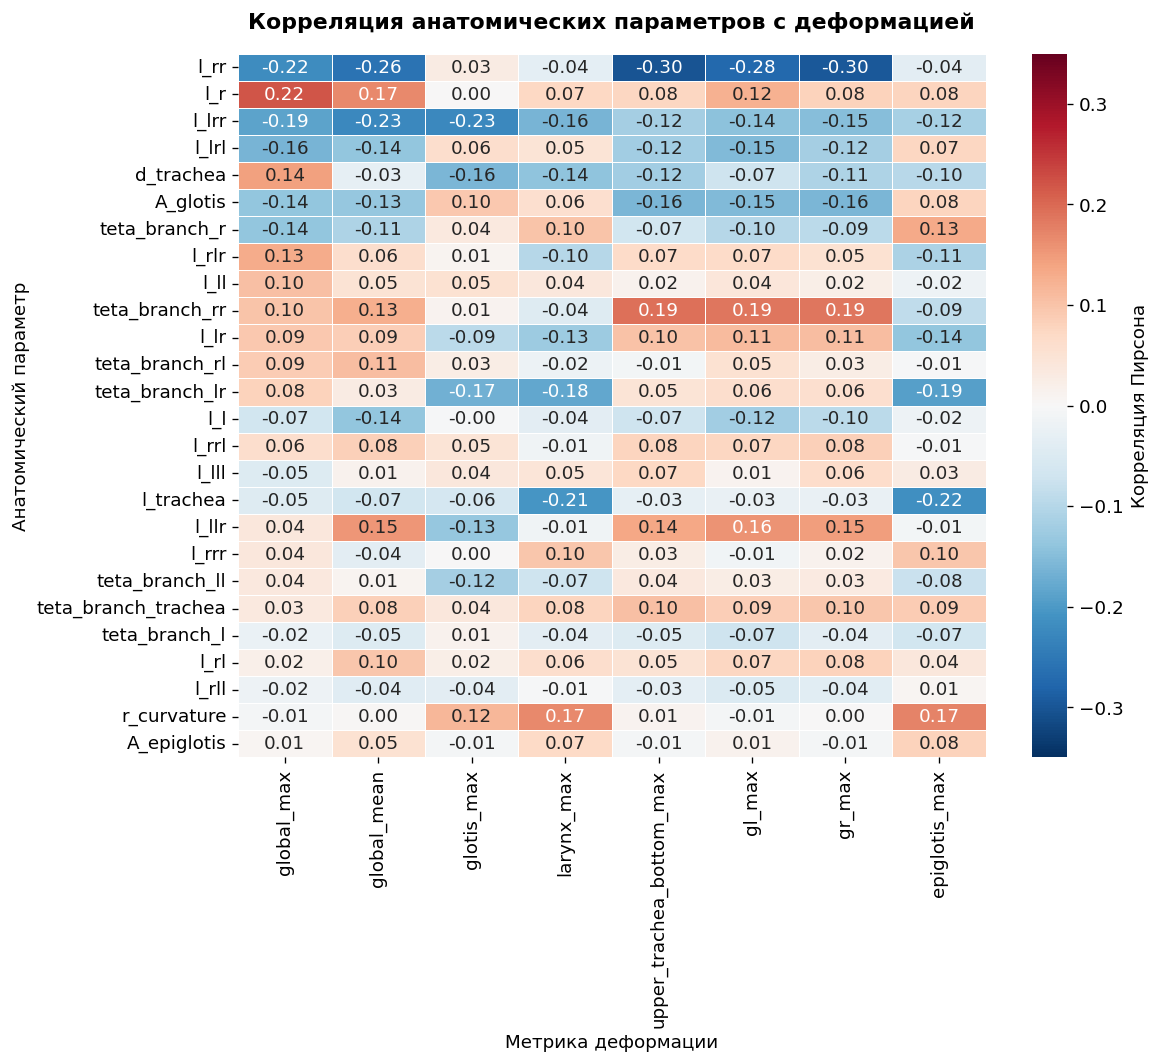

In [5]:
corr_df = pd.read_csv("correlation_results.csv", index_col=0)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr_df.astype(float),
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.35, vmax=0.35,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Корреляция Пирсона'})

ax.set_title('Корреляция анатомических параметров с деформацией',
             fontweight='bold', pad=15)
ax.set_xlabel('Метрика деформации')
ax.set_ylabel('Анатомический параметр')
plt.tight_layout()
plt.show()

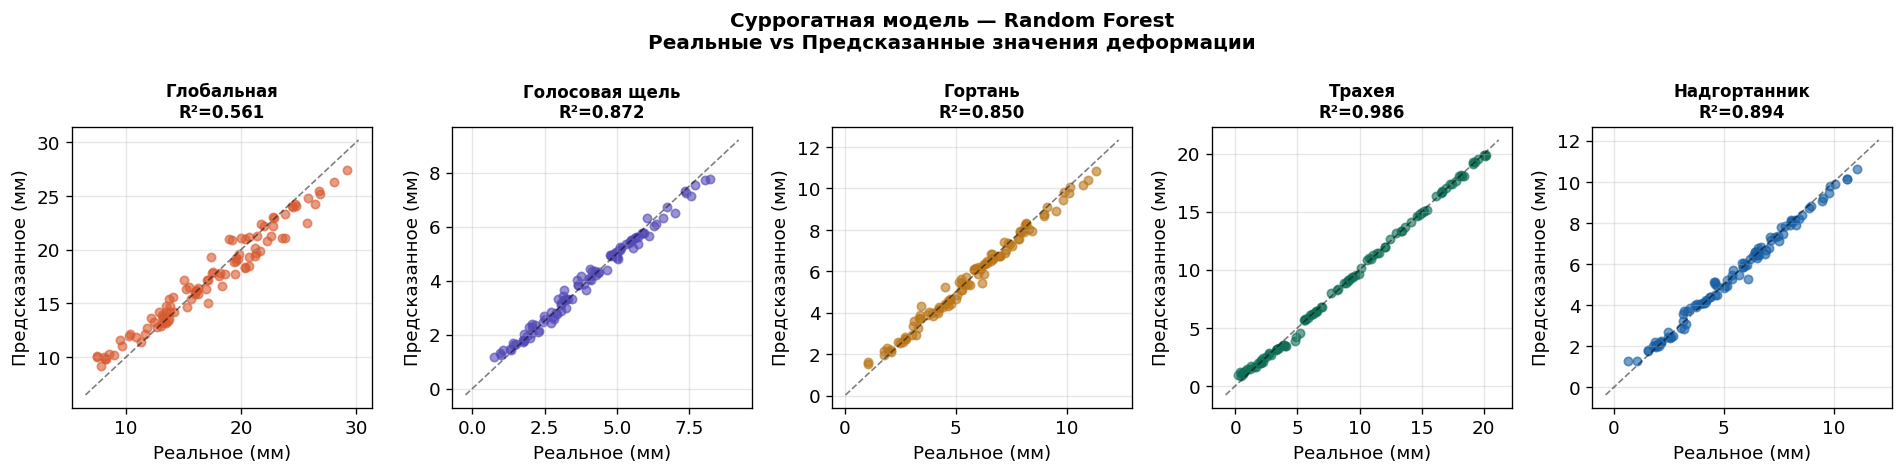

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

X = doe.drop(columns=["points"])
targets = {
    'global_max':                'Глобальная',
    'glotis_max':                'Голосовая щель',
    'larynx_max':                'Гортань',
    'upper_trachea_bottom_max':  'Трахея',
    'epiglotis_max':             'Надгортанник',
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
colors_sc = ['#D85A30','#534AB7','#BA7517','#0F6E56','#185FA5']

for i, (col, label) in enumerate(targets.items()):
    y = results[col]
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)
    pred = model.predict(X)

    cv  = KFold(n_splits=5, shuffle=True, random_state=42)
    r2s = cross_val_score(model, X, y, cv=cv, scoring='r2')

    ax = axes[i]
    ax.scatter(y, pred, alpha=0.6, color=colors_sc[i], s=25)
    lims = [min(y.min(), pred.min())-1, max(y.max(), pred.max())+1]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'{label}\nR²={r2s.mean():.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Реальное (мм)')
    ax.set_ylabel('Предсказанное (мм)')
    ax.grid(alpha=0.3)

plt.suptitle('Суррогатная модель — Random Forest\nРеальные vs Предсказанные значения деформации',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

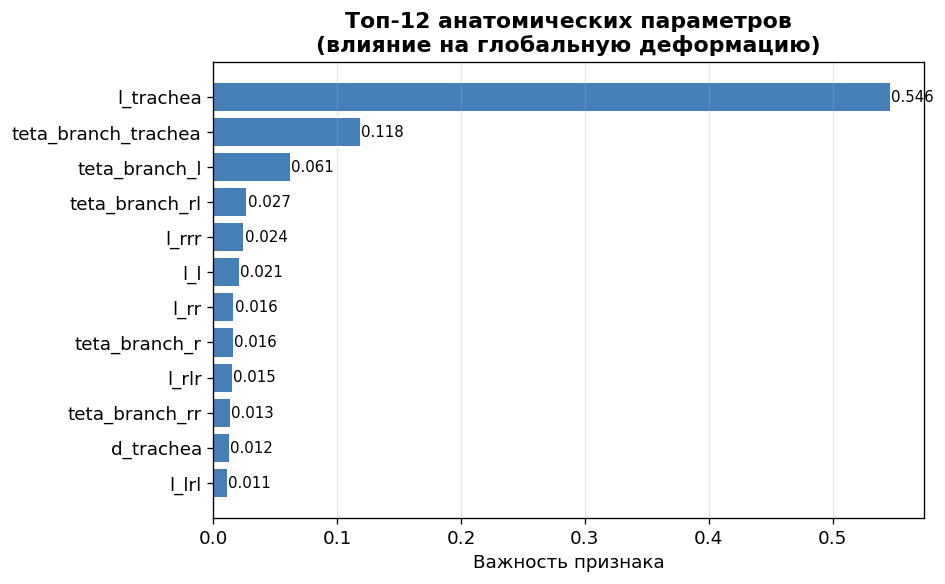

In [7]:
X = doe.drop(columns=["points"])
y = results['global_max']
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

imp = pd.Series(model.feature_importances_, index=X.columns)
imp_sorted = imp.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp_sorted.index, imp_sorted.values, color='#185FA5', alpha=0.8)
ax.set_xlabel('Важность признака')
ax.set_title('Топ-12 анатомических параметров\n(влияние на глобальную деформацию)',
             fontweight='bold')
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, imp_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()